In [2]:
# ==========================================
# Mutual Fund Analytics - EDA
# Import Libraries
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from pathlib import Path

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

print("All libraries imported successfully!")

All libraries imported successfully!


In [3]:
import os
import glob

# Load all CSV files from processed data folder
csv_files = glob.glob("data/processed/*.csv")

print("CSV Files Found:")
for file in csv_files:
    print(file)

# Load all CSVs into a dictionary
dataframes = {}

for file in csv_files:
    name = os.path.basename(file).replace(".csv", "")
    dataframes[name] = pd.read_csv(file)

print("\nLoaded DataFrames:")
print(list(dataframes.keys()))

CSV Files Found:

Loaded DataFrames:
[]


In [6]:
import os

for root, dirs, files in os.walk("data"):
    print(root)
    for file in files:
        print("   ", file)

In [7]:
import os
print(os.getcwd())
print(os.listdir())

C:\Users\Rakesh\Desktop\mf-nav-analysis\notebooks
['.ipynb_checkpoints', 'EDA_Analysis.ipynb']


In [8]:
import os

print(os.getcwd())

for root, dirs, files in os.walk("../data"):
    print(root)
    for file in files:
        print("   ", file)

C:\Users\Rakesh\Desktop\mf-nav-analysis\notebooks
../data
../data\processed
    Axis_Bluechip.csv
    HDFC_Top_100_Direct.csv
    ICICI_Bluechip.csv
    Kotak_Bluechip.csv
    nav_clean.csv
    nav_returns.csv
    Nippon_India_Large_Cap.csv
    processed_Axis_Bluechip.csv
    processed_HDFC_Top_100_Direct.csv
    processed_ICICI_Bluechip.csv
    processed_Kotak_Bluechip.csv
    processed_Nippon_India_Large_Cap.csv
    processed_sample_nav.csv
    processed_SBI_Bluechip.csv
    sample_nav.csv
    SBI_Bluechip.csv
../data\raw
    Axis_Bluechip.csv
    HDFC_Top_100_Direct.csv
    ICICI_Bluechip.csv
    Kotak_Bluechip.csv
    Nippon_India_Large_Cap.csv
    sample_nav.csv
    SBI_Bluechip.csv


In [9]:
import pandas as pd
import plotly.express as px

# Load one dataset
df = pd.read_csv("../data/raw/HDFC_Top_100_Direct.csv")

print(df.head())
print(df.columns)

         date       nav
0  19-06-2026  202.0761
1  18-06-2026  200.9565
2  17-06-2026  199.8302
3  16-06-2026  198.6152
4  15-06-2026  198.0320
Index(['date', 'nav'], dtype='str')


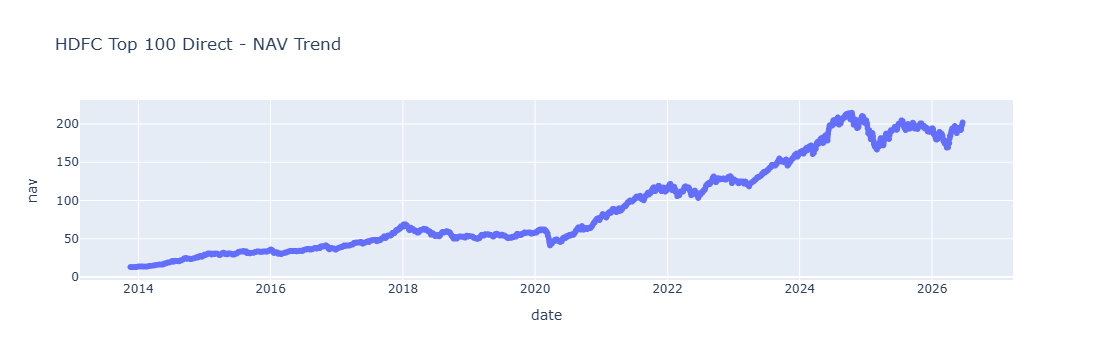

In [11]:
import pandas as pd
import plotly.express as px

# Load data
df = pd.read_csv("../data/raw/HDFC_Top_100_Direct.csv")

# Convert date column
df["date"] = pd.to_datetime(df["date"], dayfirst=True)

# Sort by date
df = df.sort_values("date")

# Plot NAV Trend
fig = px.line(
    df,
    x="date",
    y="nav",
    title="HDFC Top 100 Direct - NAV Trend",
    markers=True
)

fig.show()

In [12]:
import pandas as pd
import plotly.express as px
import glob
import os

# Read all CSV files from raw folder
files = glob.glob("../data/raw/*.csv")

all_data = []

for file in files:
    df = pd.read_csv(file)
    df["date"] = pd.to_datetime(df["date"], dayfirst=True)
    df["Fund"] = os.path.basename(file).replace(".csv", "")
    all_data.append(df)

combined_df = pd.concat(all_data)

fig = px.line(
    combined_df,
    x="date",
    y="nav",
    color="Fund",
    title="NAV Trend Analysis of All Mutual Funds"
)

fig.show()

KeyError: 'date'

In [13]:
import pandas as pd
import glob
import os

files = glob.glob("../data/raw/*.csv")

for file in files:
    print("\nFile:", os.path.basename(file))
    df = pd.read_csv(file)
    print(df.columns.tolist())


File: Axis_Bluechip.csv
['date', 'nav']

File: HDFC_Top_100_Direct.csv
['date', 'nav']

File: ICICI_Bluechip.csv
['date', 'nav']

File: Kotak_Bluechip.csv
['date', 'nav']

File: Nippon_India_Large_Cap.csv
['date', 'nav']

File: sample_nav.csv
['Date', 'NAV']

File: SBI_Bluechip.csv
['date', 'nav']


In [14]:
import pandas as pd
import glob
import os

files = glob.glob("../data/raw/*.csv")

all_data = []

for file in files:
    df = pd.read_csv(file)

    # Make all column names lowercase
    df.columns = df.columns.str.lower()

    # Convert date column
    df["date"] = pd.to_datetime(df["date"], dayfirst=True)

    # Add fund name
    df["fund"] = os.path.basename(file).replace(".csv", "")

    all_data.append(df)

combined_df = pd.concat(all_data, ignore_index=True)

print(combined_df.head())
print(combined_df.shape)

        date        nav           fund
0 2026-06-19  6195.7815  Axis_Bluechip
1 2026-06-18  6194.6520  Axis_Bluechip
2 2026-06-17  6193.3504  Axis_Bluechip
3 2026-06-16  6191.8120  Axis_Bluechip
4 2026-06-15  6187.8223  Axis_Bluechip
(19885, 3)


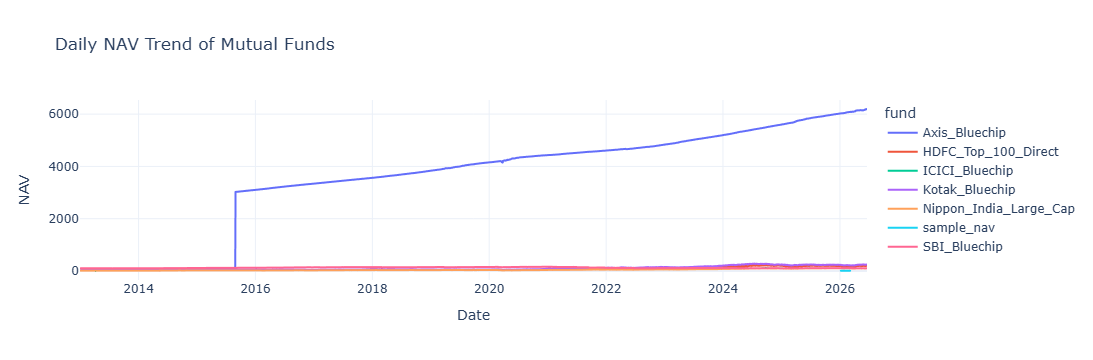

In [16]:
import plotly.express as px

fig = px.line(
    combined_df,
    x="date",
    y="nav",
    color="fund",
    title="Daily NAV Trend of Mutual Funds"
)

fig.update_layout(
    xaxis_title="Date",
    yaxis_title="NAV",
    template="plotly_white"
)

fig.show()

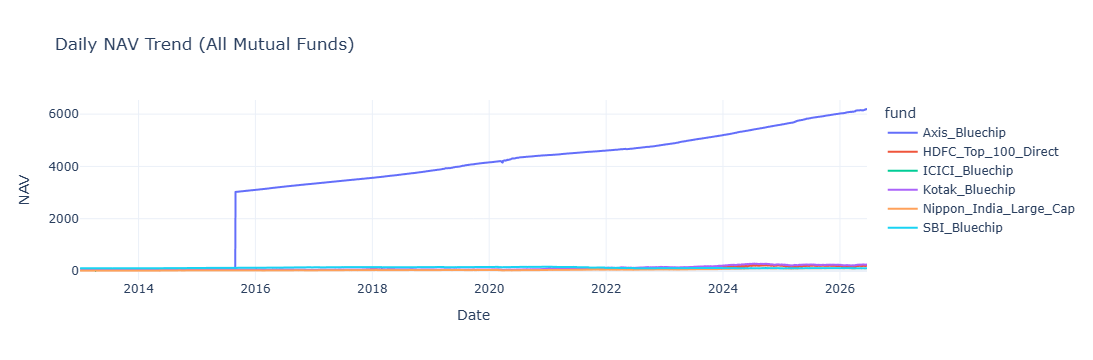

In [17]:
# Remove sample data
plot_df = combined_df[combined_df["fund"] != "sample_nav"]

import plotly.express as px

fig = px.line(
    plot_df,
    x="date",
    y="nav",
    color="fund",
    title="Daily NAV Trend (All Mutual Funds)"
)

fig.update_layout(
    xaxis_title="Date",
    yaxis_title="NAV",
    template="plotly_white"
)

fig.show()

In [19]:
print(combined_df.groupby("fund")["nav"].describe())

                         count         mean          std       min  \
fund                                                                 
Axis_Bluechip           3579.0  3401.879264  1982.900278   23.9920   
HDFC_Top_100_Direct     3105.0    90.417733    60.621453   12.7775   
ICICI_Bluechip          3321.0    56.896389    29.135998    0.0000   
Kotak_Bluechip          3315.0   102.520043    76.212102   30.5643   
Nippon_India_Large_Cap  3312.0    46.308839    27.732675   12.2191   
SBI_Bluechip            3250.0   125.742707    19.258233  102.2299   
sample_nav                 3.0    10.666667     0.152753   10.5000   

                                25%         50%          75%        max  
fund                                                                     
Axis_Bluechip           3091.552800  3854.75650  4759.758300  6195.7815  
HDFC_Top_100_Direct       40.297300    61.55480   130.847700   214.6767  
ICICI_Bluechip            32.302500    48.01920    78.443800   113.6849  

In [20]:
print(combined_df["fund"].unique())

<StringArray>
[         'Axis_Bluechip',    'HDFC_Top_100_Direct',         'ICICI_Bluechip',
         'Kotak_Bluechip', 'Nippon_India_Large_Cap',             'sample_nav',
           'SBI_Bluechip']
Length: 7, dtype: str


In [21]:
axis = pd.read_csv("../data/raw/Axis_Bluechip.csv")
print(axis.head(10))
print(axis.tail(10))
print(axis.describe())

         date        nav
0  19-06-2026  6195.7815
1  18-06-2026  6194.6520
2  17-06-2026  6193.3504
3  16-06-2026  6191.8120
4  15-06-2026  6187.8223
5  12-06-2026  6181.8148
6  11-06-2026  6179.1996
7  10-06-2026  6181.7967
8  09-06-2026  6180.6685
9  08-06-2026  6174.2084
            date      nav
3569  10-01-2013  24.0479
3570  09-01-2013  24.0424
3571  08-01-2013  24.0369
3572  07-01-2013  24.0314
3573  06-01-2013  24.0258
3574  04-01-2013  24.0147
3575  03-01-2013  24.0092
3576  02-01-2013  24.0036
3577  01-01-2013  23.9979
3578  31-12-2012  23.9920
               nav
count  3579.000000
mean   3401.879264
std    1982.900278
min      23.992000
25%    3091.552800
50%    3854.756500
75%    4759.758300
max    6195.781500


In [22]:
# Remove problematic files
plot_df = combined_df[
    (~combined_df["fund"].isin(["sample_nav", "Axis_Bluechip"]))
]

print(plot_df["fund"].unique())v

SyntaxError: invalid syntax (3507605422.py, line 6)

In [23]:
# Remove problematic files
plot_df = combined_df[
    (~combined_df["fund"].isin(["sample_nav", "Axis_Bluechip"]))
]

print(plot_df["fund"].unique())

<StringArray>
[   'HDFC_Top_100_Direct',         'ICICI_Bluechip',         'Kotak_Bluechip',
 'Nippon_India_Large_Cap',           'SBI_Bluechip']
Length: 5, dtype: str


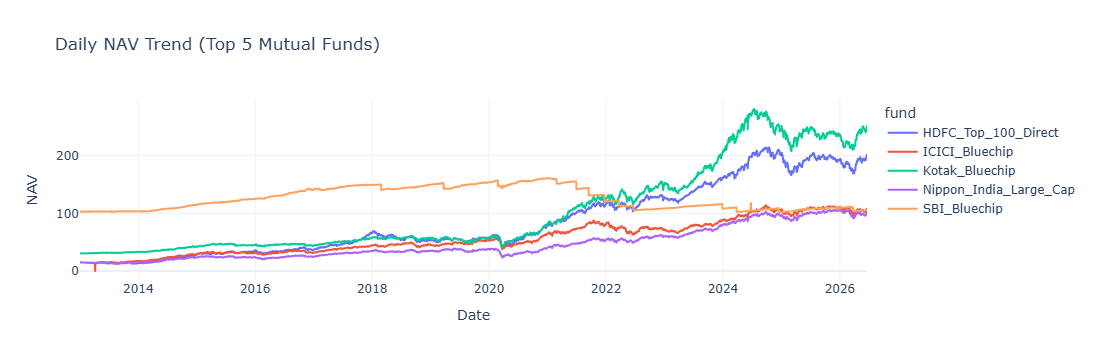

In [25]:
import plotly.express as px

fig = px.line(
    plot_df,
    x="date",
    y="nav",
    color="fund",
    title="Daily NAV Trend (Top 5 Mutual Funds)"
)

fig.update_layout(
    xaxis_title="Date",
    yaxis_title="NAV",
    template="plotly_white"
)

fig.show()

In [26]:
combined_df.describe()

,date,nav
count,19885,19885.000000
mean,2019-09-29 12:09:44.400301,681.264796
min,2012-12-31 00:00:00,0.000000
25%,2016-05-31 00:00:00,38.229000
50%,2019-09-18 00:00:00,83.076500
75%,2023-02-01 00:00:00,147.154600
max,2026-06-19 00:00:00,6195.781500
std,NaN,1528.001485


In [27]:
combined_df.isnull().sum()

date    0
nav     0
fund    0
dtype: int64

In [28]:
combined_df.duplicated().sum()

np.int64(0)

In [29]:
combined_df.groupby("fund")["nav"].max().sort_values(ascending=False)

fund
Axis_Bluechip             6195.7815
Kotak_Bluechip             281.1083
HDFC_Top_100_Direct        214.6767
SBI_Bluechip               161.3775
ICICI_Bluechip             113.6849
Nippon_India_Large_Cap     106.1272
sample_nav                  10.8000
Name: nav, dtype: float64

In [30]:
combined_df.groupby("fund")["nav"].min().sort_values()

fund
ICICI_Bluechip              0.0000
sample_nav                 10.5000
Nippon_India_Large_Cap     12.2191
HDFC_Top_100_Direct        12.7775
Axis_Bluechip              23.9920
Kotak_Bluechip             30.5643
SBI_Bluechip              102.2299
Name: nav, dtype: float64

In [31]:
combined_df = combined_df[combined_df["fund"] != "sample_nav"]

print(combined_df["fund"].unique())

<StringArray>
[         'Axis_Bluechip',    'HDFC_Top_100_Direct',         'ICICI_Bluechip',
         'Kotak_Bluechip', 'Nippon_India_Large_Cap',           'SBI_Bluechip']
Length: 6, dtype: str


In [32]:
print("Missing Values:")
print(combined_df.isnull().sum())

Missing Values:
date    0
nav     0
fund    0
dtype: int64


In [33]:
print("Duplicate Rows:", combined_df.duplicated().sum())

Duplicate Rows: 0


In [34]:
combined_df.describe()

,date,nav
count,19882,19882.000000
mean,2019-09-29 03:45:32.320692,681.365983
min,2012-12-31 00:00:00,0.000000
25%,2016-05-30 06:00:00,38.259725
50%,2019-09-18 00:00:00,83.105000
75%,2023-01-31 00:00:00,147.158950
max,2026-06-19 00:00:00,6195.781500
std,NaN,1528.094560


In [35]:
combined_df.groupby("fund")["nav"].describe()

,count,mean,std,min,25%,50%,75%,max
fund,,,,,,,,
Axis_Bluechip,3579.0,3401.879264,1982.900278,23.9920,3091.552800,3854.75650,4759.758300,6195.7815
HDFC_Top_100_Direct,3105.0,90.417733,60.621453,12.7775,40.297300,61.55480,130.847700,214.6767
ICICI_Bluechip,3321.0,56.896389,29.135998,0.0000,32.302500,48.01920,78.443800,113.6849
Kotak_Bluechip,3315.0,102.520043,76.212102,30.5643,45.992100,57.29050,145.399100,281.1083
Nippon_India_Large_Cap,3312.0,46.308839,27.732675,12.2191,24.989975,34.97005,60.246325,106.1272
SBI_Bluechip,3250.0,125.742707,19.258233,102.2299,107.988800,119.76205,145.069475,161.3775


In [36]:
combined_df.to_csv("../data/processed/combined_mutual_funds.csv", index=False)

print("Saved successfully!")

Saved successfully!


In [2]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

for fund in combined_df["fund"].unique():
    temp = combined_df[combined_df["fund"] == fund]
    plt.plot(temp["date"], temp["nav"], label=fund)

plt.title("NAV Trend of Mutual Funds")
plt.xlabel("Date")
plt.ylabel("NAV")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("../reports/charts/nav_trend.png")
plt.show()

NameError: name 'combined_df' is not defined

<Figure size 1200x600 with 0 Axes>

In [4]:
import pandas as pd

combined_df = pd.read_csv("../data/processed/combined_mutual_funds.csv")
combined_df.head()

,date,nav,fund
0,2026-06-19,6195.7815,Axis_Bluechip
1,2026-06-18,6194.6520,Axis_Bluechip
2,2026-06-17,6193.3504,Axis_Bluechip
3,2026-06-16,6191.8120,Axis_Bluechip
4,2026-06-15,6187.8223,Axis_Bluechip


In [9]:
combined_df

,date,nav,fund
0,2026-06-19,6195.7815,Axis_Bluechip
1,2026-06-18,6194.6520,Axis_Bluechip
2,2026-06-17,6193.3504,Axis_Bluechip
3,2026-06-16,6191.8120,Axis_Bluechip
4,2026-06-15,6187.8223,Axis_Bluechip
...,...,...,...
19877,2013-01-08,103.1663,SBI_Bluechip
19878,2013-01-07,103.1408,SBI_Bluechip
19879,2013-01-04,103.0619,SBI_Bluechip
19880,2013-01-03,103.0306,SBI_Bluechip


In [6]:
df

NameError: name 'df' is not defined

In [7]:
%who

combined_df	 pd	 plt	 


FileNotFoundError: [Errno 2] No such file or directory: '../reports/charts/nav_trend.png'

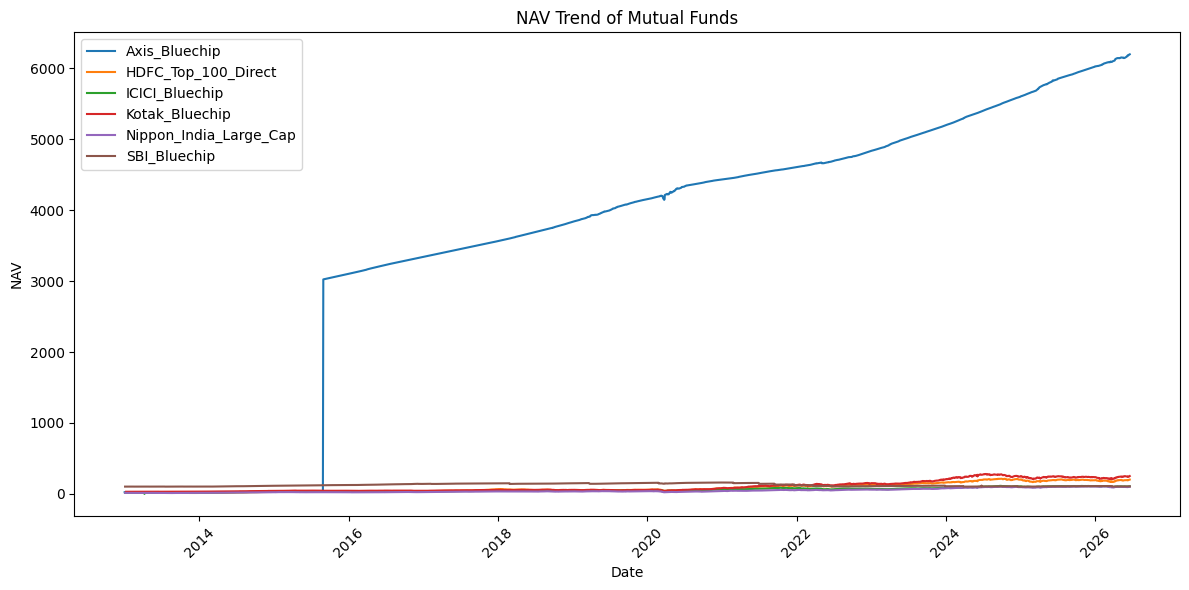

In [10]:
import matplotlib.pyplot as plt

# Convert date column to datetime
combined_df["date"] = pd.to_datetime(combined_df["date"])

plt.figure(figsize=(12,6))

for fund in combined_df["fund"].unique():
    temp = combined_df[combined_df["fund"] == fund]
    plt.plot(temp["date"], temp["nav"], label=fund)

plt.title("NAV Trend of Mutual Funds")
plt.xlabel("Date")
plt.ylabel("NAV")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("../reports/charts/nav_trend.png")
plt.show()

In [11]:
import os
print(os.getcwd())

C:\Users\Rakesh\Desktop\mf-nav-analysis\notebooks


In [12]:
import os
os.makedirs("../reports/charts", exist_ok=True)

In [13]:
plt.savefig("../reports/charts/nav_trend.png")
plt.show()

<Figure size 640x480 with 0 Axes>

In [ ]:
import matplotlib.pyplot as plt

# Convert date column to datetime
combined_df["date"] = pd.to_datetime(combined_df["date"])

plt.figure(figsize=(12,6))

for fund in combined_df["fund"].unique():
    temp = combined_df[combined_df["fund"] == fund]
    plt.plot(temp["date"], temp["nav"], label=fund)

plt.title("NAV Trend of Mutual Funds")
plt.xlabel("Date")
plt.ylabel("NAV")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("../reports/charts/nav_trend.png")
plt.show()vimport matplotlib.pyplot as plt

# Convert date column to datetime
combined_df["date"] = pd.to_datetime(combined_df["date"])

plt.figure(figsize=(12,6))

for fund in combined_df["fund"].unique():
    temp = combined_df[combined_df["fund"] == fund]
    plt.plot(temp["date"], temp["nav"], label=fund)

plt.title("NAV Trend of Mutual Funds")
plt.xlabel("Date")
plt.ylabel("NAV")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("../reports/charts/nav_trend.png")
plt.show()